In [ ]:
!pip install llama-index llama-index-readers-web llama-index-readers-file llama-index-llms-google-genai llama-index-embeddings-google-genai llama-index-vector-stores-chroma chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 67.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of selenium to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of selenium to determine which version is compatible with other requirements. Th

###**Librerías**

In [2]:
import nest_asyncio

import os
import getpass
from IPython.display import Markdown, display
from collections.abc import KeysView

#Llamaindex configuración
from llama_index.core import Settings

#Llamaindex chat model (Google)
from llama_index.llms.google_genai import GoogleGenAI

#Llamaindex documentos
from llama_index.core.schema import Document
from llama_index.readers.file.tabular.base import BaseReader

#Llamaindex lectores de información
from llama_index.readers.web import SimpleWebPageReader
from llama_index.readers.file import PDFReader, PandasCSVReader
from llama_index.core import SimpleDirectoryReader

#Llamaindex text splitters
from llama_index.core.node_parser import TokenTextSplitter, SentenceSplitter
from llama_index.core.schema import TextNode
import tiktoken
from tiktoken.core import Encoding

#Llamaindex embedding model (Google)
from llama_index.embeddings.google_genai import GoogleGenAIEmbedding

#Llamaindex vector store (Chroma)
import chromadb
from chromadb.api.client import Client
from chromadb.api.models.Collection import Collection
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader, StorageContext
from llama_index.core.indices.vector_store.retrievers.retriever import VectorIndexRetriever
from llama_index.core.query_engine.retriever_query_engine import RetrieverQueryEngine
from llama_index.core.base.response.schema import Response
from llama_index.core.schema import NodeWithScore
nest_asyncio.apply()


In [3]:
from dotenv import load_dotenv

# Load the .env file
load_dotenv()

google_api_key = os.getenv("GOOGLE_API_KEY")

In [4]:
#Ingresa el API key
#os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

###**Document Readers**

Se listan ejemplos para los principales:

*   SimpleWebPageReader
*   PDFReader
*   PandasCSVReader
*   SimpleDirectoryReader

La lista completa de document readers puede ser encontrada en la documentación:
https://developers.llamaindex.ai/python/framework-api-reference/readers/file/


####**SimpleWebPageReader**

In [5]:
#Inicializa el lector web
reader_web: SimpleWebPageReader = SimpleWebPageReader(html_to_text=True)

#Carga el contenido de la página como documentos
documento_web: list[Document] = reader_web.load_data(
    urls=["https://www.diccionariodedudas.com/reglas-ortograficas/"]
)

In [6]:
#Podemos ver que los documentos cuentan con los siguientes atributos: id, metadata, page_content y type
contenido_loader: KeysView = documento_web[0].__dict__.keys()

for contenido in contenido_loader:
    print(contenido)

id_
embedding
metadata
excluded_embed_metadata_keys
excluded_llm_metadata_keys
relationships
metadata_template
metadata_separator
text_resource
image_resource
audio_resource
video_resource
text_template


####**PDFReader**

In [7]:
import os

root_path = os.getcwd()

print(root_path)

c:\Users\Nitvn\Documentos\Dev\generative-ai-tools\langchain-llamaindex


In [9]:
#Inicializa el lector de pdf
reader_pdf: PDFReader = PDFReader()

#Carga el contenido del pdf como documentos
documento_pdf: list[Document] = reader_pdf.load_data(file=root_path + "/RAG Data/La_cultura_del_Perú.pdf")

In [10]:
#Podemos ver que los documentos cuentan con los siguientes atributos: id, metadata, page_content y type
contenido_loader: KeysView = documento_pdf[0].__dict__.keys()

for contenido in contenido_loader:
    print(contenido)

id_
embedding
metadata
excluded_embed_metadata_keys
excluded_llm_metadata_keys
relationships
metadata_template
metadata_separator
text_resource
image_resource
audio_resource
video_resource
text_template


####**PandasCSVReader**

In [12]:
#Nombres de las columnas que se leerán del archivo CSV
nombre_campos: list = [
    'User Name',
    'First Name',
    'Last Name',
    'Display Name',
    'Job Title',
    'Department',
    'Office Number',
    'Office Phone',
    'Mobile Phone',
    'Fax',
    'Address',
    'City',
    'State or Province',
    'ZIP or Postal Code',
    'Country or Region',
    'Monthly Salary (USD)'
]

#Configuración de lectura para pandas
pandas_config: dict = {"sep": ";", "usecols": nombre_campos}

#Inicializa el lector CSV
reader_csv: PandasCSVReader = PandasCSVReader(pandas_config=pandas_config)

#Carga el archivo CSV como documentos para LlamaIndex
documento_csv: list[Document] = reader_csv.load_data(
    file=root_path + "/RAG Data/Información empleados.csv"
)

In [13]:
#Podemos ver que los documentos cuentan con los siguientes atributos: id, metadata, page_content y type
contenido_loader: KeysView = documento_csv[0].__dict__.keys()

for contenido in contenido_loader:
    print(contenido)

id_
embedding
metadata
excluded_embed_metadata_keys
excluded_llm_metadata_keys
relationships
metadata_template
metadata_separator
text_resource
image_resource
audio_resource
video_resource
text_template


####**SimpleDirectoryReader**

In [15]:
extensiones_requeridas: list[str] = ['.csv']

extractores: dict[str, BaseReader] = {'.csv': PandasCSVReader(pandas_config=pandas_config)}

documentos_directorio: list[Document] = SimpleDirectoryReader(input_dir=root_path + "/RAG Data", required_exts=extensiones_requeridas, file_extractor=extractores).load_data()

In [16]:
#Podemos ver que los documentos cuentan con los siguientes atributos: id, metadata, page_content y type
contenido_loader: KeysView = documentos_directorio[0].__dict__.keys()

for contenido in contenido_loader:
    print(contenido)

id_
embedding
metadata
excluded_embed_metadata_keys
excluded_llm_metadata_keys
relationships
metadata_template
metadata_separator
text_resource
image_resource
audio_resource
video_resource
text_template


###**Text splitters**

Se listan ejemplos para los principales:

*   TokenTextSplitter
*   SentenceSplitter

La lista completa de text splitters puede ser encontrada en la documentación: https://developers.llamaindex.ai/python/framework-api-reference/node_parsers/

####**TokenTextSplitter**

In [17]:
#Inicializa el tokenizador
tokenizer: Encoding = tiktoken.get_encoding("cl100k_base")

In [18]:
#Configura el separador de texto por tokens
splitter_token: TokenTextSplitter = TokenTextSplitter(
    chunk_size=500,
    chunk_overlap=0,
    separator="\n",
    tokenizer=tokenizer.encode
)

#Divide los documentos en nodos de texto
nodes_token: list[TextNode] = splitter_token.get_nodes_from_documents(documento_pdf)

In [19]:
#Contenido de cada nodo
for node in nodes_token:
    print(f"Metadata {node.metadata} \nText: {node.text}")

Metadata {'page_label': '1', 'file_name': 'La_cultura_del_Perú.pdf'} 
Text: La historia del Perú
El Perú ha tenido un desarrollo histórico amplio y nunca ajeno a los acontecimientos mundiales. La proyección e inﬂuencia 
cultural del Perú ha sido un factor de relevancia mayor en la Historia de América del Sur desde la expansión del Imperio 
Inca, seguido por la creación del Virreinato del Perú, hasta la fundación de la República en 1821. Desde la llegada de los 
primeros pobladores hasta nuestros días, el Perú se ha nutrido y fortalecido con la vertiente andina, española, africana, 
china, japonesa e italiana, generando una sociedad multicultural y multiétnica de rápida adecuación a nuevos tiempos, 
caracterizada por una gran receptividad ante lo foráneo, llegando a crear uno de los focos culturales más importantes de 
América así como todo un referente económico y ejemplo de camino al desarrollo más destacado de los últimos años en la 
región.Los primeros pobladores llegaron al Perú ha

####**SentenceSplitter**

In [20]:
#Configura el separador de texto por oraciones
splitter_sentence: SentenceSplitter = SentenceSplitter(
    chunk_size = 500,
    chunk_overlap = 0,
    separator = "\n",
    tokenizer = tokenizer.encode #opcional
)

#Divide los documentos en nodos de texto
nodes_sentence: list[TextNode] = splitter_sentence.get_nodes_from_documents(documento_pdf)

In [21]:
#Contenido de cada nodo
for node in nodes_sentence:
    print(f"Metadata {node.metadata} \nText: {node.text}")

Metadata {'page_label': '1', 'file_name': 'La_cultura_del_Perú.pdf'} 
Text: La historia del Perú
El Perú ha tenido un desarrollo histórico amplio y nunca ajeno a los acontecimientos mundiales. La proyección e inﬂuencia 
cultural del Perú ha sido un factor de relevancia mayor en la Historia de América del Sur desde la expansión del Imperio 
Inca, seguido por la creación del Virreinato del Perú, hasta la fundación de la República en 1821. Desde la llegada de los 
primeros pobladores hasta nuestros días, el Perú se ha nutrido y fortalecido con la vertiente andina, española, africana, 
china, japonesa e italiana, generando una sociedad multicultural y multiétnica de rápida adecuación a nuevos tiempos, 
caracterizada por una gran receptividad ante lo foráneo, llegando a crear uno de los focos culturales más importantes de 
América así como todo un referente económico y ejemplo de camino al desarrollo más destacado de los últimos años en la 
región.Los primeros pobladores llegaron al Perú ha

###**Text Embeddings**

En este ejemplo usaremos el modelo de embeddings disponible en Google: **gemini-embedding-001**

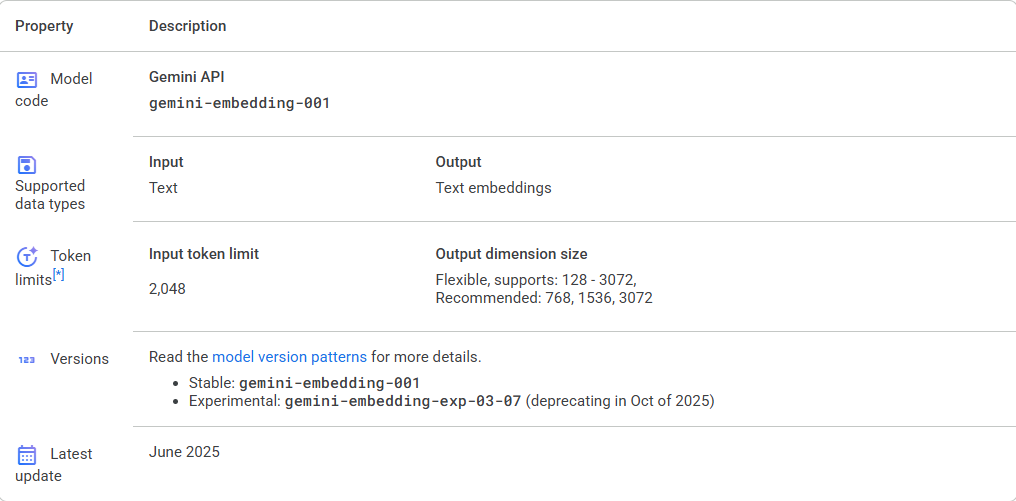

Documentación: https://ai.google.dev/gemini-api/docs/embeddings

In [22]:
#El módulo GoogleGenerativeAIEmbeddings nos permite acceder al modelo de gemini
embedding_model = GoogleGenAIEmbedding(model="models/gemini-embedding-001")
embedding_vector = embedding_model.get_text_embedding("Creando un vector embedding")

#Luego de utilizar el método embed_query podemos obtener un vector de embeddings
embedding_vector[:5]

2026-07-04 18:27:29,783 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-2-preview:batchEmbedContents "HTTP/1.1 200 OK"


[-0.04503158, 0.0023852892, -0.015782604, 0.0034555134, 0.0029613061]

###**Vector Stores**

Las bases de datos vectorizadas nos van a permitir almacenar nuestros embeddings y recuperar textos en base a funciones de similitud calculadas sobre los vectores de embeddings.

Para este ejemplo utilizaremos la base de datos vectorizada: ChromaDB

Documentación: https://developers.llamaindex.ai/python/examples/vector_stores/chromaindexdemo/

In [23]:
#Configura el modelo para generación de texto
Settings.llm = GoogleGenAI(model="gemini-2.5-flash", temperature=0)

#Configura el modelo de embeddings
Settings.embed_model = GoogleGenAIEmbedding(model="models/gemini-embedding-001")

2026-07-04 18:27:50,877 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash "HTTP/1.1 200 OK"


In [24]:
#Cliente de Chroma con almacenamiento persistente
db: Client = chromadb.PersistentClient(path="./chroma_db2")

#Colección para los documentos RAG
db_coleccion: Collection = db.get_or_create_collection("documentos_RAG")

In [25]:
#Crea el vector store usando la colección de Chroma
vector_store: ChromaVectorStore = ChromaVectorStore(chroma_collection=db_coleccion)

#Configura el contexto de almacenamiento para LlamaIndex
almacenamiento: StorageContext = StorageContext.from_defaults(vector_store=vector_store)

In [26]:
# Crea el índice a partir de los nodos y el almacenamiento
vector_index: VectorStoreIndex = VectorStoreIndex.from_documents(documents=nodes_sentence, storage_context=almacenamiento)

# Crea un retriever para buscar documentos relevantes
retriever: VectorIndexRetriever = vector_index.as_retriever(retriever_mode='embedding')

# Crea el motor de consulta
query_engine: RetrieverQueryEngine = vector_index.as_query_engine(similarity_top_k=3)

2026-07-04 18:28:59,165 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-2-preview:batchEmbedContents "HTTP/1.1 200 OK"


### **RAG**

In [27]:
def chat_rag(pregunta: str):
    """
    Genera una respuesta utilizando un enfoque de recuperación aumentada (RAG).

    Parámetros
    ----------
    pregunta : str
        Pregunta o consulta del usuario.

    Retorna
    -------
    respuesta : Any
        Respuesta generada por el motor de consulta.
    """
    retrieved_nodes: list[NodeWithScore] = retriever.retrieve(pregunta)
    respuesta: Response = query_engine.query(pregunta)
    return respuesta

In [28]:
pregunta: str = "¿Cuál fue la organización estatal más extensa e importante de la Sudamérica precolombina?"

respuesta: Response = chat_rag(pregunta)

display(Markdown(respuesta.response))

2026-07-04 18:31:19,700 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-2-preview:batchEmbedContents "HTTP/1.1 200 OK"
2026-07-04 18:31:20,340 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-2-preview:batchEmbedContents "HTTP/1.1 200 OK"
2026-07-04 18:31:20,369 - INFO - AFC is enabled with max remote calls: 10.
2026-07-04 18:31:22,493 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


La organización estatal más extensa e importante de la Sudamérica precolombina fue el Imperio Inca.